# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [11]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [12]:
# Inspect the shapes of the datasets
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
Class_Number= len(class_names)
print(Class_Number)
print(f'Before one-hot encoding: {y_train[2]}')
y_train = to_categorical(y_train, num_classes=Class_Number)
y_test = to_categorical(y_test, num_classes=Class_Number)
print(f'After one-hot encoding: {y_train[2]}')



X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
10
Before one-hot encoding: 0
After one-hot encoding: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


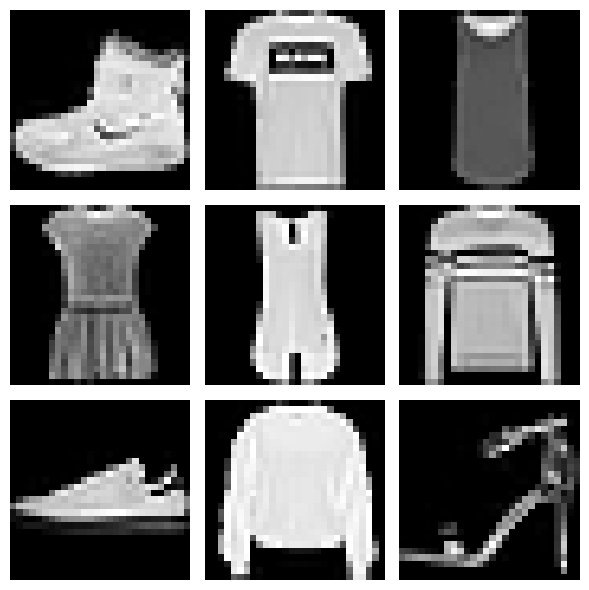

In [19]:
import matplotlib.pyplot as plt
num_rows, num_cols = 3, 3
plt.figure(figsize=(6, 6))

for i in range(num_rows * num_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

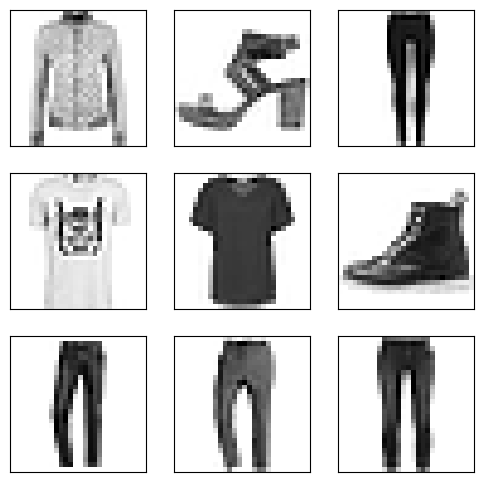

In [ ]:
# Selecting 9 random indices
random_indices = np.random.choice(len(X_train), 9, replace=False)

# Creating a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Looks like what I expected.. the quality seems low but better than the Numbers dataset.  But this will still be challenging to distinguish between different items, particularly pants which look pretty much the same from what I have seen.**

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [28]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Input(shape=(28, 28)))   # Input tensor specifying the shape 28 x 28
model.add(Flatten()) # 2D to 1D
model.add(Dense(28))  # 28 neurons. No activation
model.add(Dense(Class_Number))  # 10 neurons,  no activations

# Compile the model using `model.compile()`
model.compile(
    loss='categorical_crossentropy', # Loss function that is useful for multi-class classification
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

# Train the model with `model.fit()`
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step - accuracy: 0.1014 - loss: 9.1484 - val_accuracy: 0.0968 - val_loss: 7.7193
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step - accuracy: 0.1012 - loss: 7.8384 - val_accuracy: 0.0969 - val_loss: 7.7797
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 643us/step - accuracy: 0.1026 - loss: 7.8318 - val_accuracy: 0.0969 - val_loss: 8.0967
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 583us/step - accuracy: 0.1020 - loss: 7.9800 - val_accuracy: 0.0969 - val_loss: 7.8213
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 573us/step - accuracy: 0.1009 - loss: 8.0768 - val_accuracy: 0.0969 - val_loss: 8.1558
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - accuracy: 0.0993 - loss: 8.1278
Loss:     8.09
Accuracy: 10.19%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Performance is terrible..10% accurate. kinda what I would expect considering that I the neural network is small and there are no activations used.  Need much better hyperparameters, more neurons and activations to improve.**

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [ ]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
# Input layer
model.add(Input(shape=(28,28,1)))  # Input tensor specifying the shape needed as described above
model.add(Conv2D(filters=64, kernel_size=(6, 6), activation='relu'))

model.add(Flatten()) #flatten before giving to output layer
# Output layer
model.add(Dense(10, activation='softmax'))  # 10 neurons, softmax activation

model.compile(
    loss='categorical_crossentropy', # Loss function that is useful for multi-class classification
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

# Train the model
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)


# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6886 - loss: 0.9159 - val_accuracy: 0.8149 - val_loss: 0.5271
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8245 - loss: 0.5055 - val_accuracy: 0.8344 - val_loss: 0.4643
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8474 - loss: 0.4488 - val_accuracy: 0.8441 - val_loss: 0.4434
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8588 - loss: 0.4118 - val_accuracy: 0.8635 - val_loss: 0.3940
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8677 - loss: 0.3823 - val_accuracy: 0.8708 - val_loss: 0.3751
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8671 - loss: 0.3932
Loss:     0.39
Accuracy: 86.54%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Huge improvement!  Up to 87% from 10%.  I think the biggest improvement came from the fact of training on 2D data and using relu activation**

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [33]:
# A. Test Hyperparameters
# am the most curious about the filters.. i set them to 64 so I will go lower and higher to see the impact
filters = [10, 32, 64, 128, 256]
resultsDict = {}

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

for filter in filters:

    # Create a simple CNN model
    print(filter)
    model = Sequential()
    # Input layer
    model.add(Input(shape=(28,28,1)))  # Input tensor specifying the shape needed as described above
    model.add(Conv2D(filters=filter, kernel_size=(6, 6), activation='relu'))

    model.add(Flatten()) #flatten before giving to output layer
    # Output layer
    model.add(Dense(10, activation='softmax'))  # 10 neurons, softmax activation

    model.compile(
        loss='categorical_crossentropy', # Loss function that is useful for multi-class classification
        optimizer='sgd', # Optimizer
        metrics=['accuracy'] # Metrics to evaluate the model
    )

    # Train the model
    model.fit(
        X_train, # Training data
        y_train, # Training labels
        epochs=5, # Number of epochs
        batch_size=32, # Number of samples per batch
        validation_split=0.2 # Use 20% of the data for validation
    )


    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test)
    resultsDict[filter] = [loss, accuracy]
    print(f'Filter={filter}  Loss:     {loss:.2f}')
    print(f'Filter={filter} Accuracy: {accuracy*100:.2f}%')

resultsDict

10
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6680 - loss: 0.9565 - val_accuracy: 0.8031 - val_loss: 0.5519
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8158 - loss: 0.5198 - val_accuracy: 0.8212 - val_loss: 0.4954
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8355 - loss: 0.4719 - val_accuracy: 0.8456 - val_loss: 0.4373
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8528 - loss: 0.4270 - val_accuracy: 0.8590 - val_loss: 0.4131
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8627 - loss: 0.3999 - val_accuracy: 0.8628 - val_loss: 0.3980
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8565 - loss: 0.4168
Filter=10  Loss:     0.42
Filter=10 Accuracy: 85.51%
32
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6767 - loss: 0.9472 - val_accuracy: 0.8118 - val_loss: 0.5305
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8201 - loss: 0.5111 - val

{10: [0.4187919497489929, 0.8550999760627747],
 32: [0.4293835461139679, 0.8483999967575073],
 64: [0.3926713764667511, 0.8673999905586243],
 128: [0.4016430675983429, 0.8590999841690063],
 256: [0.4093153178691864, 0.8586999773979187]}

In [32]:
# B. Test presence or absence of regularization
#try the same model above, but using dropout regularization

from keras.layers import Conv2D,Dropout

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
# Input layer
model.add(Input(shape=(28,28,1)))  # Input tensor specifying the shape needed as described above
model.add(Conv2D(filters=64, kernel_size=(6, 6), activation='relu')) #keeping at 64 just for consistency
model.add(Dropout(0.3))  


model.add(Flatten()) #flatten before giving to output layer
# Output layer
model.add(Dense(10, activation='softmax'))  # 10 neurons, softmax activation

model.compile(
    loss='categorical_crossentropy', # Loss function that is useful for multi-class classification
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

# Train the model
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)


# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6775 - loss: 0.9352 - val_accuracy: 0.8163 - val_loss: 0.5185
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8204 - loss: 0.5162 - val_accuracy: 0.8393 - val_loss: 0.4564
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8414 - loss: 0.4568 - val_accuracy: 0.8487 - val_loss: 0.4344
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8561 - loss: 0.4176 - val_accuracy: 0.8565 - val_loss: 0.4082
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8635 - loss: 0.3945 - val_accuracy: 0.8625 - val_loss: 0.3886
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8601 - loss: 0.4056
Loss:     0.41
Accuracy: 85.51%


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**I thought filters would make a difference, particularly over the range I selected (10-256) but the accuracy was pretty much the same results.  Same when I added dropout regularization.  So I guess the parameters selected didn't really impact the model.  I want to try again but add another layer to pick up some additional patterns perhaps**

In [34]:

from keras.layers import Conv2D,Dropout

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
# Input layer
model.add(Input(shape=(28,28,1)))  # Input tensor specifying the shape needed as described above
model.add(Conv2D(filters=64, kernel_size=(6, 6), activation='relu')) #keeping at 64 just for consistency
model.add(Dropout(0.3))  

#add another layer to improve prediction
model.add(Conv2D(filters=64, kernel_size=(6, 6), activation='relu')) #keeping at 64 just for consistency
model.add(Dropout(0.3))  

model.add(Flatten()) #flatten before giving to output layer
# Output layer
model.add(Dense(10, activation='softmax'))  # 10 neurons, softmax activation

model.compile(
    loss='categorical_crossentropy', # Loss function that is useful for multi-class classification
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

# Train the model
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)


# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.6474 - loss: 0.9992 - val_accuracy: 0.8271 - val_loss: 0.4941
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 38ms/step - accuracy: 0.8186 - loss: 0.5026 - val_accuracy: 0.8442 - val_loss: 0.4337
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.8450 - loss: 0.4384 - val_accuracy: 0.8591 - val_loss: 0.3984
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.8571 - loss: 0.3978 - val_accuracy: 0.8663 - val_loss: 0.3693
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 61s 40ms/step - accuracy: 0.8696 - loss: 0.3696 - val_accuracy: 0.8731 - val_loss: 0.3504
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8754 - loss: 0.3640
Loss:     0.37
Accuracy: 86.95%


# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [ ]:
#see run above where I added another layer.. no improvement really. Im stuck at 86%

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**I saw a big jump in performance from my baseline by adding relu activation and using 2D images before flattening.  Unfortunately, nothing a did afterwards (adding dropout, increasing the number of filters and layers) really did anything to improve the model.** 

**If I had more time, I would add momentum and improved learning rate experiments to see their effect on the training**

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.